# Exercício 1 - Análise de Dados - Construindo a Análise <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/pandas/pandas-original.svg" height="45" />📊

![Jupyter](https://img.shields.io/badge/Jupyter-111827?style=flat-square&logo=jupyter&logoColor=F37626)
![Python](https://img.shields.io/badge/Python-111827?style=flat-square&logo=python&logoColor=3776AB)
![Python Version](https://img.shields.io/badge/python-3.14+-blue)
![Tópico](https://img.shields.io/badge/tópico-exercício%20%7C%20pandas%20%7C%20análise-teal)
![Dificuldade](https://img.shields.io/badge/dificuldade-Intermediário-yellow)
![Pré-req](https://img.shields.io/badge/pré--req-pandas%20%7C%20groupby-purple)
![Biblioteca](https://img.shields.io/badge/requer-pyodbc%20%2B%20pandas%20%2B%20matplotlib-orange)

> Com a conexão e a estrutura já mapeadas no notebook anterior, agora é hora de transformar `VendasEmpresa` em resposta pra perguntas de negócio: quanto a empresa faturou, quem vendeu mais, o que mais saiu e como o faturamento se comportou ao longo do ano.

## 📋 Conteúdo

1. [Carregando os Dados com pandas](#-1-carregando-os-dados-com-pandas)
2. [Faturamento Total e por Categoria](#-2-faturamento-total-e-por-categoria)
3. [Ranking de Vendedores](#-3-ranking-de-vendedores)
4. [Produtos Mais Vendidos](#-4-produtos-mais-vendidos)
5. [Evolução Mensal do Faturamento](#-5-evolução-mensal-do-faturamento)


## 📥 1. Carregando os Dados com pandas

Um único `pd.read_sql` traz a tabela inteira pra memória — dali em diante, é análise pura de pandas, sem precisar voltar no banco pra cada pergunta.

In [1]:
import pandas as pd
from conexao import nova_conexao_sqlserver
from cores import *

conexao = nova_conexao_sqlserver(banco="HashtagCursoSQL")
df_vendas = pd.read_sql("SELECT * FROM dbo.VendasEmpresa", conexao)
conexao.close()

df_vendas["DataVenda"] = pd.to_datetime(df_vendas["DataVenda"])
df_vendas["Faturamento"] = df_vendas["Quantidade"] * df_vendas["ValorUnitario"]

df_vendas.head()


/var/folders/4w/0rjmw_hx1t1fqxbgbqbyn8_h0000gn/T/ipykernel_27536/3681429344.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vendas = pd.read_sql("SELECT * FROM dbo.VendasEmpresa", conexao)


,Id,Produto,Categoria,Quantidade,ValorUnitario,DataVenda,Vendedor,Faturamento
0,1,Estante,Móveis,2,3055.01,2025-10-21,Bruno Lima,6110.02
1,2,"Monitor 27""",Eletrônicos,7,3478.56,2025-02-22,Bruno Lima,24349.92
2,3,Mochila,Papelaria,10,1583.91,2025-04-17,Bruno Lima,15839.10
3,4,Agenda,Papelaria,6,1507.25,2025-11-18,Elaine Rocha,9043.50
4,5,Aspirador de Pó,Casa,2,738.07,2025-05-05,Ana Souza,1476.14


## 💰 2. Faturamento Total e por Categoria

Com a coluna `Faturamento` calculada, `.sum()` e `.groupby()` respondem a primeira pergunta óbvia: quanto entrou, e de onde.

Faturamento total do ano: R$ 2,881,927.06

Faturamento por categoria:
  Móveis: R$ 856,637.27
  Eletrônicos: R$ 809,590.97
  Papelaria: R$ 631,320.30
  Casa: R$ 584,378.52


<Axes: title={'center': 'Faturamento por Categoria'}, xlabel='Categoria'>

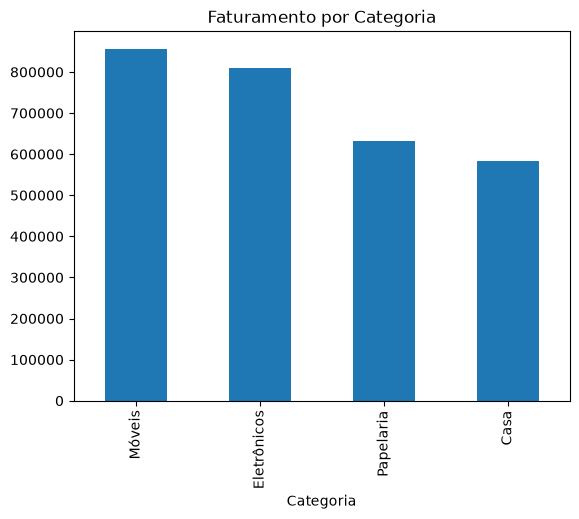

In [2]:
faturamento_total = df_vendas["Faturamento"].sum()
print(f"{CinzaClaro}Faturamento total do ano:{Reset} {VerdeClaro}R$ {faturamento_total:,.2f}{Reset}\n")

faturamento_por_categoria = df_vendas.groupby("Categoria")["Faturamento"].sum().sort_values(ascending=False)
print(f"{CinzaClaro}Faturamento por categoria:{Reset}")
for categoria, valor in faturamento_por_categoria.items():
    print(f"  {VerdeClaro}{categoria}{Reset}: R$ {valor:,.2f}")

faturamento_por_categoria.plot(kind="bar", title="Faturamento por Categoria")


## 🏆 3. Ranking de Vendedores

Agrupando por `Vendedor` em vez de `Categoria`, o mesmo padrão de código responde quem mais faturou.

In [3]:
ranking_vendedores = df_vendas.groupby("Vendedor")["Faturamento"].sum().sort_values(ascending=False)

print(f"{CinzaClaro}Ranking de vendedores por faturamento:{Reset}")
for posicao, (vendedor, valor) in enumerate(ranking_vendedores.items(), start=1):
    print(f"  {MagentaClaro}{posicao}º{Reset} {VerdeClaro}{vendedor}{Reset}: R$ {valor:,.2f}")


Ranking de vendedores por faturamento:
  1º Diego Alves: R$ 655,557.49
  2º Elaine Rocha: R$ 611,299.27
  3º Bruno Lima: R$ 571,715.47
  4º Carla Dias: R$ 552,927.29
  5º Ana Souza: R$ 490,427.54


## 📦 4. Produtos Mais Vendidos

Aqui o agrupamento é por quantidade, não por faturamento — um produto barato pode vender muito mais unidades do que um caro.

Top 5 produtos por quantidade vendida:
  Mesa de Escritório: 139 unidades
  Agenda: 118 unidades
  Aspirador de Pó: 112 unidades
  Luminária de Mesa: 111 unidades
  Cadeira Gamer: 107 unidades


<Axes: title={'center': 'Top 5 Produtos por Quantidade'}, ylabel='Produto'>

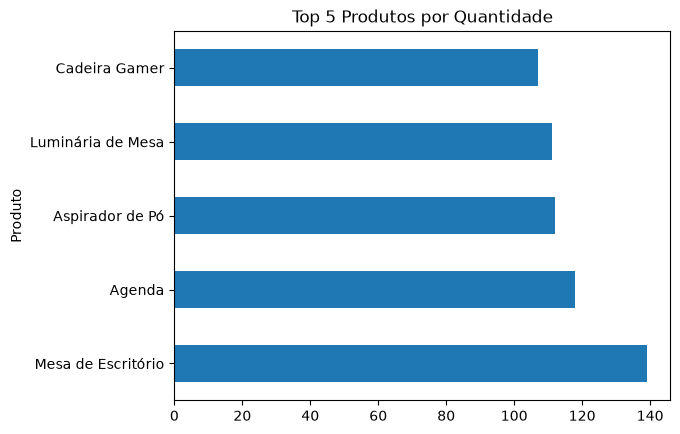

In [4]:
top_produtos_quantidade = df_vendas.groupby("Produto")["Quantidade"].sum().sort_values(ascending=False).head(5)

print(f"{CinzaClaro}Top 5 produtos por quantidade vendida:{Reset}")
for produto, quantidade in top_produtos_quantidade.items():
    print(f"  {VerdeClaro}{produto}{Reset}: {quantidade} unidades")

top_produtos_quantidade.plot(kind="barh", title="Top 5 Produtos por Quantidade")


## 📈 5. Evolução Mensal do Faturamento

Extraindo o mês de `DataVenda` com `.dt.to_period("M")`, dá pra ver a tendência de faturamento ao longo do ano — igual ao padrão usado nos módulos de pandas.

Faturamento mês a mês:
  2025-01: R$ 244,951.87
  2025-02: R$ 373,833.03
  2025-03: R$ 312,490.08
  2025-04: R$ 213,922.83
  2025-05: R$ 137,322.70
  2025-06: R$ 360,004.97
  2025-07: R$ 181,656.40
  2025-08: R$ 143,082.92
  2025-09: R$ 210,275.03
  2025-10: R$ 173,001.39
  2025-11: R$ 289,367.26
  2025-12: R$ 242,018.58


<Axes: title={'center': 'Faturamento Mensal'}, xlabel='MesAno'>

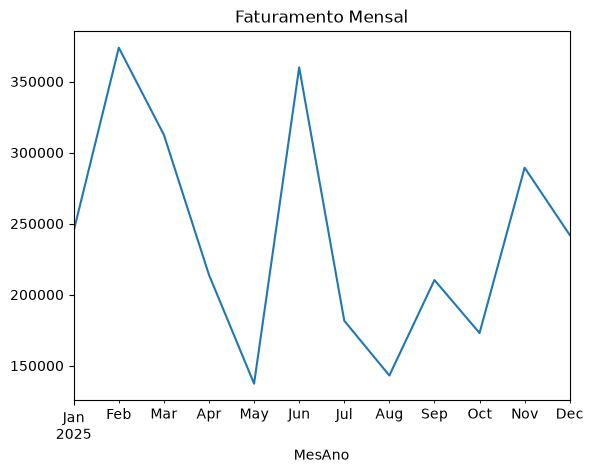

In [5]:
df_vendas["MesAno"] = df_vendas["DataVenda"].dt.to_period("M")
faturamento_mensal = df_vendas.groupby("MesAno")["Faturamento"].sum()

print(f"{CinzaClaro}Faturamento mês a mês:{Reset}")
for mes, valor in faturamento_mensal.items():
    print(f"  {VerdeClaro}{mes}{Reset}: R$ {valor:,.2f}")

faturamento_mensal.plot(title="Faturamento Mensal")


Com uma conexão `pyodbc`, um `pd.read_sql` e algumas linhas de `groupby`, a base bruta virou 4 respostas de negócio: faturamento total, ranking de vendedores, produtos mais vendidos e a evolução mensal. É esse o valor de saber puxar dado direto do banco em vez de esperar alguém exportar um Excel.

> ▶️ Próximo notebook: **Exercício 2 - CRUD - Controle de Estoque - Apresentação**.